# CCF — DataFrame Implementation

**Connected Component Finder** using the PySpark **DataFrame API**.

> Kardes et al., *CCF: Fast and Scalable Connected Component Computation in MapReduce*

### Differences vs the RDD version
| | RDD | DataFrame |
|---|---|---|
| API | Low-level, functional | High-level, SQL-like |
| Optimizer | None | Catalyst + Tungsten |
| CCF-Iterate | `groupByKey` + custom reducer | `groupBy` + `min` + `join` |
| CCF-Dedup | `distinct()` | `dropDuplicates()` |
| Plan growth | Linear (accumulates) | Breaks with `localCheckpoint()` |

> **Before running:** make sure the data files exist by running `python/generate_graphs.py` first.

## 1. Setup & Configuration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, sys, subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyspark', 'matplotlib', '-q'], check=True)

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# local[*] -> embedded; spark://spark-master:7077 -> Docker cluster
SPARK_MASTER = 'local[*]'
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data' if IN_COLAB else os.path.join(os.path.dirname(os.getcwd()), 'data')
CKPT_DIR = os.path.join(DATA_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# Verify that graphs have been generated
REQUIRED = ['graph_small.txt', 'graph_medium.txt', 'graph_large.txt']
missing = [f for f in REQUIRED if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(
        f"Missing graph files: {missing}\n"
        f"Run python/generate_graphs.py first (generates files in {DATA_DIR})"
    )

print(f'Spark master : {SPARK_MASTER}')
print(f'Data dir     : {DATA_DIR}')
print(f'Graphs found : {REQUIRED}')

Spark master : local[*]
Data dir     : /content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data
Graphs found : ['graph_small.txt', 'graph_medium.txt', 'graph_large.txt']


## 2. Start SparkSession

In [3]:
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import LongType

spark = (
    SparkSession.builder
    .appName('CCF-DataFrame-Notebook')
    .master(SPARK_MASTER)
    .config('spark.ui.showConsoleProgress', 'false')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
spark.sparkContext.setCheckpointDir(CKPT_DIR)

print(f'Spark version : {spark.version}')
print(f'Master        : {spark.sparkContext.master}')
print(f'Checkpoint dir: {CKPT_DIR}')

Spark version : 4.0.2
Master        : local[*]
Checkpoint dir: /content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data/checkpoints


## 3. Load edges

In [4]:
def load_edges(spark, path):
    """Load an edge list and add reverse edges to make the graph bidirectional."""
    raw = (
        spark.read
        .option('comment', '#')
        .option('sep', ' ')
        .csv(path)
        .toDF('node', 'neighbor')
        .select(
            F.col('node').cast(LongType()),
            F.col('neighbor').cast(LongType()),
        )
        .filter(F.col('node').isNotNull() & F.col('neighbor').isNotNull())
    )
    return raw.union(
        raw.select(F.col('neighbor').alias('node'), F.col('node').alias('neighbor'))
    ).dropDuplicates()

small_path = os.path.join(DATA_DIR, 'graph_small.txt')
edge_df = load_edges(spark, small_path)
edge_df.cache()
print(f'Edges loaded: {edge_df.count()}')
edge_df.show(5)

Edges loaded: 2000
+----+--------+
|node|neighbor|
+----+--------+
| 116|     364|
| 309|     460|
| 340|     406|
| 430|      79|
| 147|     121|
+----+--------+
only showing top 5 rows


## 4. CCF-Iterate

1. Compute per-node minimum neighbour with `groupBy` + `min`
2. Join back the full adjacency list
3. Keep only active nodes where `min_neighbor < node`
4. Emit `(node, min_neighbor)` — main pairs
5. Emit `(v, min_neighbor)` for every other neighbour — **new pairs** (convergence signal)

In [5]:
def ccf_iterate(df):
    """One CCF-Iterate step using DataFrame operations.

    Returns (combined_pairs_df, new_pair_count) where combined_pairs_df still
    carries a boolean '_new' column so the caller can count new pairs *after*
    checkpointing — avoiding a second heap-materialisation of the raw plan.
    """
    # Re-add the reverse of every pair so the algorithm can propagate
    # component labels through chains (essential from iteration 2 onwards)
    bidirectional = df.union(
        df.select(F.col('neighbor').alias('node'), F.col('node').alias('neighbor'))
    )

    # Find the minimum neighbour for each node (future component label)
    min_df = bidirectional.groupBy('node').agg(F.min('neighbor').alias('min_neighbor'))

    # Keep only nodes whose minimum neighbour is smaller than themselves
    active = bidirectional.join(min_df, on='node').filter(F.col('min_neighbor') < F.col('node'))

    # Main pair: assign node to its min-neighbour component (_new=False)
    main_pairs = (
        active.select(F.col('node'), F.col('min_neighbor').alias('neighbor'),
                      F.lit(False).alias('_new'))
        .distinct()
    )

    # New pairs: link other neighbours to the min component (_new=True)
    other_pairs = (
        active
        .filter(F.col('neighbor') != F.col('min_neighbor'))
        .select(F.col('neighbor').alias('node'),
                F.col('min_neighbor').alias('neighbor'),
                F.lit(True).alias('_new'))
    )

    return main_pairs.union(other_pairs)


## 5. CCF-Dedup + main loop

> **Note:** `localCheckpoint()` is called every iteration to truncate the query plan
> and prevent `OutOfMemoryError: Java heap space` from plan-tree explosion.

In [6]:
def run_ccf(spark, edge_df):
    """Full CCF loop. Returns (result_df, iterations, per_iter_stats).

    Memory note: the convergence flag (_new column) is counted from the
    already-checkpointed result — one materialisation per iteration instead
    of two, which avoids OOM on large graphs.
    """
    # localCheckpoint() breaks the lineage so the query plan stays O(1) per iteration
    current = edge_df.localCheckpoint(eager=True)
    iteration = 0
    per_iter = []   # list of (iteration, pair_count, new_pairs, elapsed_s)
    while True:
        iteration += 1
        t_iter = time.time()

        iterated = ccf_iterate(current)

        # Checkpoint once; _new flag is preserved inside the checkpoint
        deduped = iterated.dropDuplicates(['node', 'neighbor']).localCheckpoint(eager=True)

        # Both counts come from the single materialised checkpoint (cheap scans)
        count     = deduped.count()
        new_pairs = deduped.filter(F.col('_new')).count()

        dt = time.time() - t_iter
        per_iter.append((iteration, count, new_pairs, round(dt, 3)))
        print(f'  Iteration {iteration}: {count} pairs, newPairs={new_pairs}  ({dt:.2f}s)')

        current = deduped.drop('_new')
        if new_pairs == 0:
            break
    return current, iteration, per_iter


## 6. Correctness test (paper Figure 5)

Edges: (0,1),(1,2),(1,3),(3,4),(5,6),(6,7)  
Expected: **2 components** — {0,1,2,3,4} and {5,6,7}

In [7]:
paper_edges_raw = [(0,1),(1,2),(1,3),(3,4),(5,6),(6,7)]
paper_df = spark.createDataFrame(paper_edges_raw, ['node', 'neighbor']).select(
    F.col('node').cast(LongType()), F.col('neighbor').cast(LongType())
).union(
    spark.createDataFrame(paper_edges_raw, ['node', 'neighbor']).select(
        F.col('neighbor').cast(LongType()).alias('node'),
        F.col('node').cast(LongType()).alias('neighbor')
    )
).dropDuplicates()

res_paper, iters_paper, _ = run_ccf(spark, paper_df)
comps = res_paper.select('neighbor').distinct().count()
print(f'\nResult: {comps} components in {iters_paper} iterations  '
      f"{('PASS' if comps == 2 else 'FAIL')} (expected 2)")

  Iteration 1: 10 pairs, newPairs=4  (3.04s)
  Iteration 2: 8 pairs, newPairs=2  (1.61s)
  Iteration 3: 6 pairs, newPairs=0  (1.56s)

Result: 2 components in 3 iterations  PASS (expected 2)


## 7. Run on graph_small — detailed iteration trace

In [8]:
t0 = time.time()
result_df, n_iters, per_iter = run_ccf(spark, edge_df)
elapsed = time.time() - t0

num_components = result_df.select('neighbor').distinct().count()

print(f"\n{'='*45}")
print(f'Graph        : graph_small.txt')
print(f'Iterations   : {n_iters}')
print(f'Components   : {num_components}')
print(f'Elapsed time : {elapsed:.3f}s')
print(f"{'='*45}")

print(f"\n{'Iter':>5} {'Pairs':>8} {'NewPairs':>10} {'Time (s)':>10}")
print('-' * 37)
for it, cnt, np_, dt in per_iter:
    print(f'{it:>5} {cnt:>8,} {np_:>10,} {dt:>10.3f}')

  Iteration 1: 1582 pairs, newPairs=1194  (16.11s)
  Iteration 2: 2357 pairs, newPairs=1888  (2.28s)
  Iteration 3: 2086 pairs, newPairs=1591  (1.34s)
  Iteration 4: 641 pairs, newPairs=142  (1.48s)
  Iteration 5: 499 pairs, newPairs=0  (1.23s)

Graph        : graph_small.txt
Iterations   : 5
Components   : 1
Elapsed time : 26.885s

 Iter    Pairs   NewPairs   Time (s)
-------------------------------------
    1    1,582      1,194     16.108
    2    2,357      1,888      2.278
    3    2,086      1,591      1.339
    4      641        142      1.476
    5      499          0      1.234


## 8. Sample component assignment

In [9]:
result_df.withColumnRenamed('neighbor', 'component_id').orderBy('node').show(20)

+----+------------+
|node|component_id|
+----+------------+
|   2|           1|
|   3|           1|
|   4|           1|
|   5|           1|
|   6|           1|
|   7|           1|
|   8|           1|
|   9|           1|
|  10|           1|
|  11|           1|
|  12|           1|
|  13|           1|
|  14|           1|
|  15|           1|
|  16|           1|
|  17|           1|
|  18|           1|
|  19|           1|
|  20|           1|
|  21|           1|
+----+------------+
only showing top 20 rows


## 9. Run on all graph sizes

In [10]:
results = []
all_per_iter = {}

for name in ['graph_small.txt', 'graph_medium.txt', 'graph_large.txt']:
    path = os.path.join(DATA_DIR, name)
    print(f'\n── {name} ──')
    df = load_edges(spark, path)
    df.cache()
    n_edges = df.count()
    t0 = time.time()
    res, iters, pit = run_ccf(spark, df)
    elapsed = time.time() - t0
    n_comp = res.select('neighbor').distinct().count()
    results.append({'graph': name, 'edges': n_edges, 'iterations': iters,
                    'components': n_comp, 'time_s': round(elapsed, 3)})
    all_per_iter[name] = pit

hdr = f"{'Graph':<25} {'Edges':>10} {'Iters':>7} {'Components':>12} {'Time (s)':>10}"
print('\n' + hdr)
print('-' * len(hdr))
for r in results:
    print(f"{r['graph']:<25} {r['edges']:>10,} {r['iterations']:>7} {r['components']:>12} {r['time_s']:>10}")


── graph_small.txt ──
  Iteration 1: 1582 pairs, newPairs=1194  (13.53s)
  Iteration 2: 2357 pairs, newPairs=1888  (1.36s)
  Iteration 3: 2086 pairs, newPairs=1591  (1.82s)
  Iteration 4: 641 pairs, newPairs=142  (2.64s)
  Iteration 5: 499 pairs, newPairs=0  (1.85s)

── graph_medium.txt ──
  Iteration 1: 90566 pairs, newPairs=81544  (27.76s)
  Iteration 2: 151612 pairs, newPairs=141710  (2.46s)
  Iteration 3: 42651 pairs, newPairs=32654  (4.85s)
  Iteration 4: 10009 pairs, newPairs=10  (1.68s)
  Iteration 5: 9999 pairs, newPairs=0  (1.07s)

── graph_large.txt ──
  Iteration 1: 909097 pairs, newPairs=818878  (57.68s)
  Iteration 2: 1656237 pairs, newPairs=1557207  (13.48s)
  Iteration 3: 1408637 pairs, newPairs=1308648  (15.12s)
  Iteration 4: 126640 pairs, newPairs=26641  (9.35s)
  Iteration 5: 99999 pairs, newPairs=0  (5.31s)

Graph                          Edges   Iters   Components   Time (s)
--------------------------------------------------------------------
graph_small.txt      

## 10. Visualisation

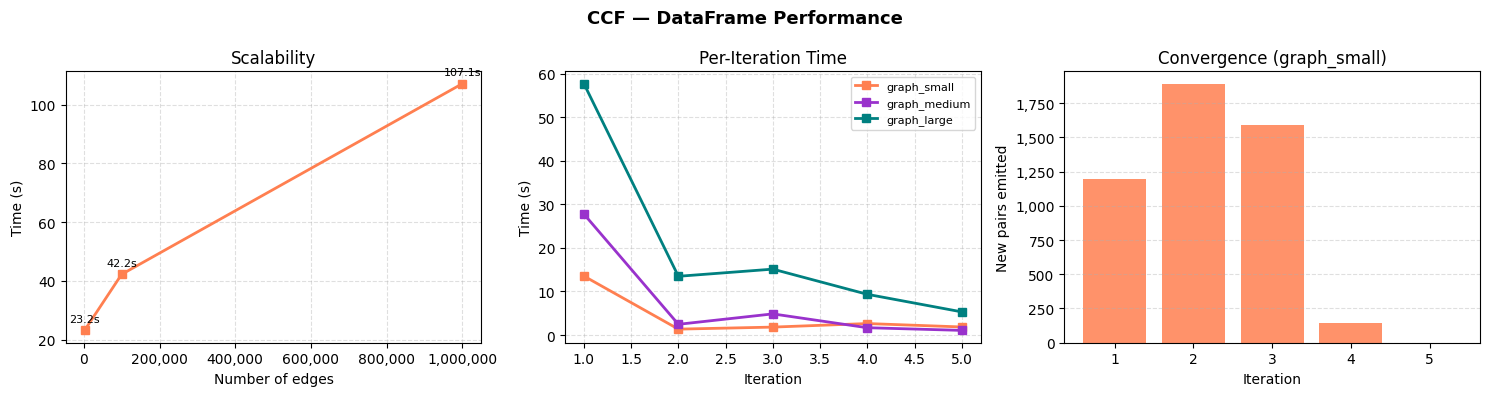

Saved to /content/drive/MyDrive/Colab Notebooks/M2_Projects/Big Data/data/dataframe_results.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('CCF — DataFrame Performance', fontsize=13, fontweight='bold')

C = 'coral'

# ── 1. Scalability ────────────────────────────────────────────────────────────
ax1 = axes[0]
edges_v = [r['edges'] for r in results]
times_v = [r['time_s'] for r in results]
ax1.plot(edges_v, times_v, marker='s', color=C, lw=2)
for e, t in zip(edges_v, times_v):
    ax1.annotate(f'{t:.1f}s', xy=(e, t), xytext=(0, 6), textcoords='offset points',
                 ha='center', fontsize=8)
ax1.set_xlabel('Number of edges'); ax1.set_ylabel('Time (s)')
ax1.set_title('Scalability')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.grid(linestyle='--', alpha=0.4)

# ── 2. Per-iteration time for each graph ──────────────────────────────────────
ax2 = axes[1]
colors = ['coral', 'darkorchid', 'teal']
for idx, (name, pit) in enumerate(all_per_iter.items()):
    iters = [p[0] for p in pit]
    times = [p[3] for p in pit]
    ax2.plot(iters, times, marker='s', color=colors[idx % len(colors)],
             label=name.replace('.txt', ''), lw=2)
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Time (s)')
ax2.set_title('Per-Iteration Time')
ax2.legend(fontsize=8); ax2.grid(linestyle='--', alpha=0.4)

# ── 3. New pairs per iteration — convergence signal (graph_small) ─────────────
ax3 = axes[2]
key_small = 'graph_small.txt'
if key_small in all_per_iter:
    pit_s   = all_per_iter[key_small]
    iters_s = [p[0] for p in pit_s]
    new_p   = [p[2] for p in pit_s]
    ax3.bar(iters_s, new_p, color=C, alpha=0.85)
    ax3.set_xlabel('Iteration'); ax3.set_ylabel('New pairs emitted')
    ax3.set_title('Convergence (graph_small)')
    ax3.set_xticks(iters_s)
    ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax3.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
out_path = os.path.join(DATA_DIR, 'dataframe_results.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

In [12]:
spark.stop()